# 📱 Samsung Marketing Channel Effectiveness Analysis
### Using Logarithmic Functions to Identify Diminishing Returns

**Dataset:** Samsung Galaxy product campaigns across 10 channels, 3 regions, and 3 product tiers  
**Concept (Unit 2.6):** Log functions capture diminishing returns — equal log(spend) steps represent exponentially larger actual spends, making cross-channel comparison fair.

---

## Step 1: Setup & Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()  # Upload: samsung_marketing_dataset.csv

df = pd.read_csv('samsung_marketing_dataset.csv')
print('Dataset shape:', df.shape)
print('\nChannels:',      df['channel'].unique().tolist())
print('Products:',        df['product_name'].unique().tolist())
print('Product Tiers:',   df['product_tier'].unique().tolist())
print('Regions:',         df['region'].unique().tolist())
df.head()

Saving samsung_marketing_dataset.csv to samsung_marketing_dataset.csv
Dataset shape: (240, 25)

Channels: ['Google Ads', 'Meta (FB/Instagram)', 'YouTube', 'TikTok', 'Influencer', 'Email', 'LinkedIn', 'OTT/CTV', 'WhatsApp Business', 'SEO/Content']
Products: ['Galaxy A15', 'Galaxy A35', 'Galaxy M55', 'Galaxy F55', 'Galaxy S24', 'Galaxy S24 Ultra', 'Galaxy Z Fold 6', 'Galaxy Z Flip 6']
Product Tiers: ['Budget', 'Mid-range', 'Flagship']
Regions: ['Tier-3', 'Tier-2', 'Metro']


,campaign_id,product_name,product_tier,channel,region,campaign_quarter,launch_phase,price_inr,popularity_score,brand_search_volume,...,clicks,leads_generated,conversions,units_sold,revenue_generated_inr,customer_acquisition_cost_inr,roas,log_ad_spend,log_revenue,marginal_return
0,SAM-2001,Galaxy A15,Budget,Google Ads,Tier-3,Q1-2024,Launch,15000,7.2,85000,...,36268,3136,682,21,310377.44,7613.29,1.941,11.9822,12.6455,0.553498
1,SAM-2002,Galaxy A15,Budget,Google Ads,Tier-3,Q2-2024,Growth,15000,7.2,85000,...,26839,2385,819,20,298646.12,4986.75,2.994,11.5103,12.6070,0.962391
2,SAM-2003,Galaxy A15,Budget,Google Ads,Tier-2,Q3-2024,Launch,15000,7.2,85000,...,39130,11033,4089,49,671504.08,3481.80,3.936,12.0471,13.4173,1.182921
3,SAM-2004,Galaxy A15,Budget,Meta (FB/Instagram),Tier-2,Q1-2024,Maturity,15000,7.2,85000,...,27876,5294,2108,17,242384.93,5731.47,2.488,11.4869,12.3983,0.863343
4,SAM-2005,Galaxy A15,Budget,Meta (FB/Instagram),Tier-3,Q2-2024,Growth,15000,7.2,85000,...,47515,7443,1838,27,374256.11,8705.22,1.592,12.3675,12.8327,0.436230


## Step 2: Channel-Level Overview

In [ ]:
channel_summary = df.groupby('channel').agg(
    campaigns        = ('campaign_id',            'count'),
    total_spend_inr  = ('ad_spend_inr',           'sum'),
    total_revenue    = ('revenue_generated_inr',  'sum'),
    total_units_sold = ('units_sold',             'sum'),
    avg_roas         = ('roas',                   'mean'),
    avg_cac          = ('customer_acquisition_cost_inr', 'mean')
).reset_index()

channel_summary['overall_roas'] = (
    channel_summary['total_revenue'] / channel_summary['total_spend_inr']
)

channel_summary = channel_summary.sort_values('overall_roas', ascending=False)
print('=== Channel Summary ===')
print(channel_summary.to_string(index=False))

=== Channel Summary ===
            channel  campaigns  total_spend_inr  total_revenue  total_units_sold   avg_roas     avg_cac  overall_roas
              Email         24          1132325   200576234.05              2043 164.297042  869.432917    177.136630
        SEO/Content         24          1854114   176897495.77              1860 122.074583 1513.680000     95.408101
  WhatsApp Business         24          1968637   127163626.07              1464  74.855458 1609.211667     64.594756
           LinkedIn         24          4118138   211676515.18              1938  53.759375 3183.179583     51.401025
         Influencer         24          5527528   229582236.43              2294  35.386417 3368.116250     41.534342
             TikTok         24          3312708   135616156.56              1449  34.351208 2683.189167     40.938156
         Google Ads         24         10097283   373975194.62              3633  30.131708 3997.439167     37.037210
            YouTube         24  

## Step 3: Apply Log Transformation

**Why:** From Samsung material (Section 2.6) — `log(x+1)` transforms skewed spend/revenue data into a normalized scale and reveals the diminishing-returns curve naturally.

In [ ]:
# Apply natural log (shift +1 to avoid log(0) — same pattern from class code)
df['log_spend']   = np.log(df['ad_spend_inr'] + 1)
df['log_revenue'] = np.log(df['revenue_generated_inr'] + 1)

# Show original vs log-transformed side by side
print('Original vs Log-transformed values:')
print(df[['channel','ad_spend_inr','log_spend','revenue_generated_inr','log_revenue']].head(10).to_string(index=False))

Original vs Log-transformed values:
            channel  ad_spend_inr  log_spend  revenue_generated_inr  log_revenue
         Google Ads        159879  11.982179              310377.44    12.645548
         Google Ads         99735  11.510282              298646.12    12.607018
         Google Ads        170608  12.047130              671504.08    13.417277
Meta (FB/Instagram)         97435  11.486951              242384.93    12.398286
Meta (FB/Instagram)        235041  12.367520              374256.11    12.832698
Meta (FB/Instagram)         65920  11.096212              434397.18    12.981717
            YouTube         57065  10.951964              235220.47    12.368283
            YouTube         43247  10.674706              262972.86    12.479810
            YouTube        134752  11.811199              522113.64    13.165642
             TikTok         76858  11.249728              254635.01    12.447590


## Step 4: Logarithmic Efficiency & Marginal Return per Channel

In [ ]:
log_metrics = df.groupby('channel').agg(
    avg_log_spend   = ('log_spend',       'mean'),
    avg_log_revenue = ('log_revenue',     'mean'),
    avg_marginal    = ('marginal_return', 'mean')
).reset_index()

# Log efficiency: how much log-revenue per unit of log-spend
log_metrics['log_efficiency'] = (
    log_metrics['avg_log_revenue'] / log_metrics['avg_log_spend']
)

log_metrics = log_metrics.sort_values('log_efficiency', ascending=False)
print('=== Log Metrics by Channel ===')
print(log_metrics.to_string(index=False))

=== Log Metrics by Channel ===
            channel  avg_log_spend  avg_log_revenue  avg_marginal  log_efficiency
              Email      10.568063        14.891182     74.881363        1.409074
        SEO/Content      11.053450        14.927498     49.988153        1.350483
  WhatsApp Business      11.161468        14.828921     29.722087        1.328582
             TikTok      11.677690        14.770462     10.881443        1.264845
           LinkedIn      11.684948        14.744229     17.034932        1.261814
         Influencer      12.075385        15.058106     10.088610        1.247008
            YouTube      12.496883        15.278434      6.184652        1.222580
Meta (FB/Instagram)      12.490736        15.218192      6.518572        1.218358
         Google Ads      12.746914        15.504977      7.068039        1.216371
            OTT/CTV      12.551393        15.205228      8.821771        1.211437


## Step 5: Visualise — Channel Effectiveness (4-panel)

/tmp/ipykernel_506/266423751.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(marg['channel'], rotation=45, ha='right', fontsize=8)


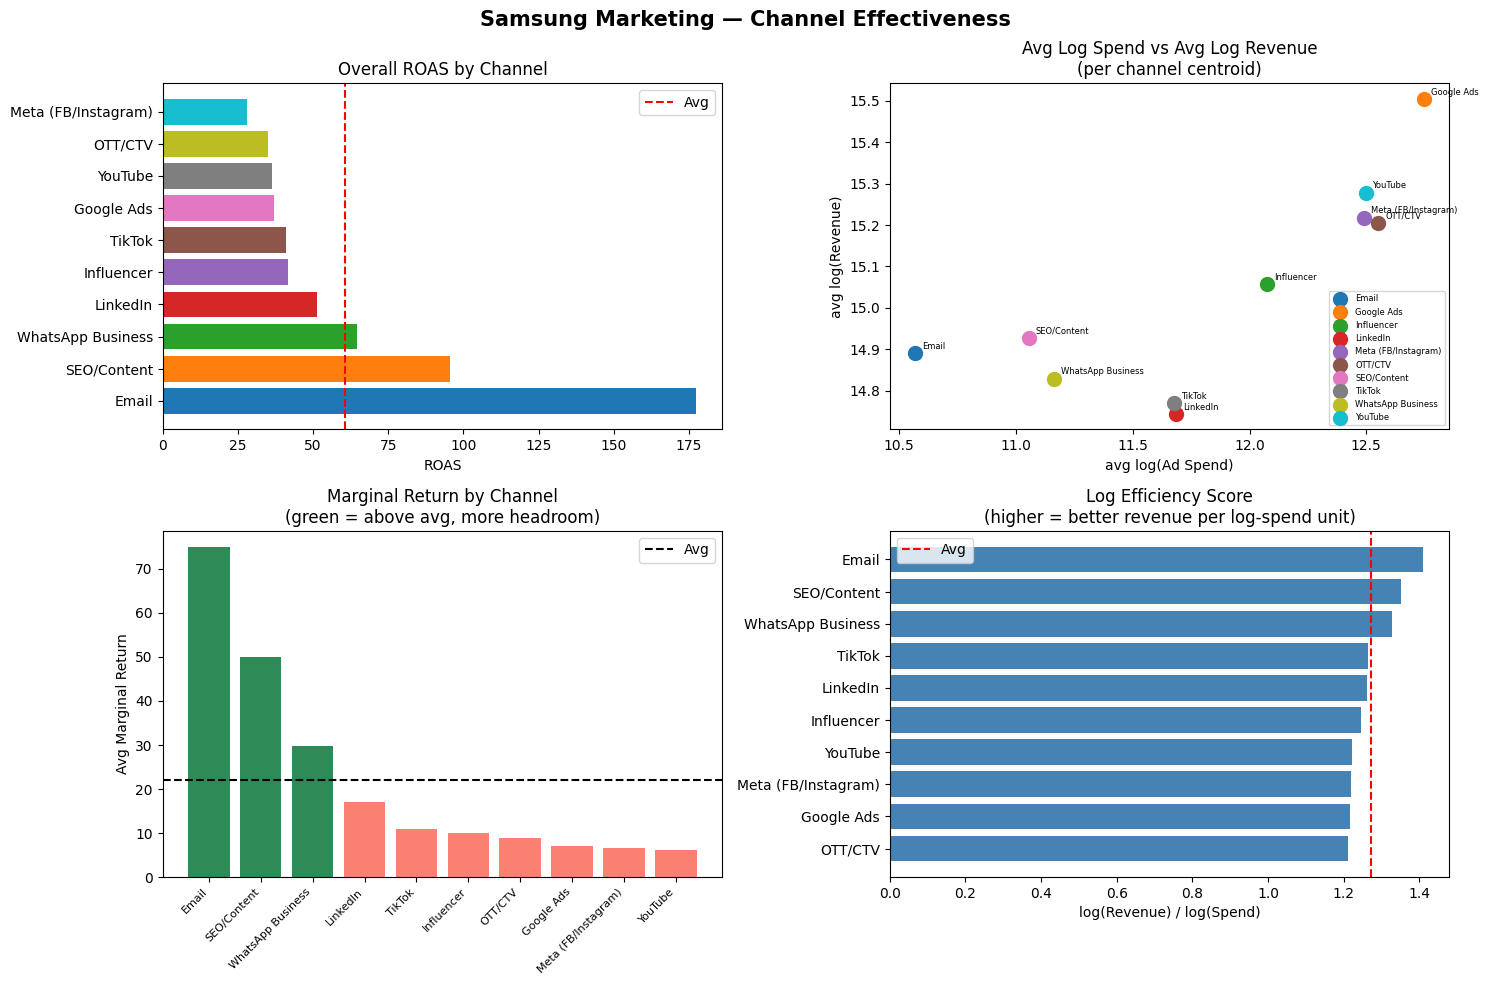

Chart saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Samsung Marketing — Channel Effectiveness', fontsize=15, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, len(channel_summary)))

# --- Plot 1: ROAS by Channel ---
ax1 = axes[0, 0]
ax1.barh(channel_summary['channel'], channel_summary['overall_roas'], color=colors)
ax1.axvline(channel_summary['overall_roas'].mean(), color='red', linestyle='--', label='Avg')
ax1.set_xlabel('ROAS')
ax1.set_title('Overall ROAS by Channel')
ax1.legend()

# --- Plot 2: Log Spend vs Log Revenue (averaged per channel) ---
ax2 = axes[0, 1]
channel_avg = df.groupby('channel').agg(
    avg_log_spend   = ('log_spend',   'mean'),
    avg_log_revenue = ('log_revenue', 'mean')
).reset_index()
colors_avg = plt.cm.tab10(np.linspace(0, 1, len(channel_avg)))
for j, row in channel_avg.iterrows():
    ax2.scatter(row['avg_log_spend'], row['avg_log_revenue'],
                label=row['channel'], color=colors_avg[j], s=100, zorder=5)
    ax2.annotate(row['channel'], (row['avg_log_spend'], row['avg_log_revenue']),
                 textcoords='offset points', xytext=(5, 3), fontsize=6)
ax2.set_xlabel('avg log(Ad Spend)')
ax2.set_ylabel('avg log(Revenue)')
ax2.set_title('Avg Log Spend vs Avg Log Revenue\n(per channel centroid)')
ax2.legend(fontsize=6, loc='lower right')

# --- Plot 3: Marginal Return ---
ax3 = axes[1, 0]
marg = log_metrics.sort_values('avg_marginal', ascending=False)
bar_cols = ['seagreen' if v >= marg['avg_marginal'].mean() else 'salmon' for v in marg['avg_marginal']]
ax3.bar(marg['channel'], marg['avg_marginal'], color=bar_cols)
ax3.axhline(marg['avg_marginal'].mean(), color='black', linestyle='--', label='Avg')
ax3.set_xticklabels(marg['channel'], rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Avg Marginal Return')
ax3.set_title('Marginal Return by Channel\n(green = above avg, more headroom)')
ax3.legend()

# --- Plot 4: Log Efficiency Score ---
ax4 = axes[1, 1]
eff = log_metrics.sort_values('log_efficiency', ascending=True)
ax4.barh(eff['channel'], eff['log_efficiency'], color='steelblue')
ax4.axvline(eff['log_efficiency'].mean(), color='red', linestyle='--', label='Avg')
ax4.set_xlabel('log(Revenue) / log(Spend)')
ax4.set_title('Log Efficiency Score\n(higher = better revenue per log-spend unit)')
ax4.legend()

plt.tight_layout()
plt.savefig('samsung_channel_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## Step 6: Diminishing Returns Curves — Log vs Linear Model per Channel

From Samsung material (pages 70–71): comparing log model vs linear model per channel shows where spend is still productive (steep log curve) vs saturated (flat log curve).

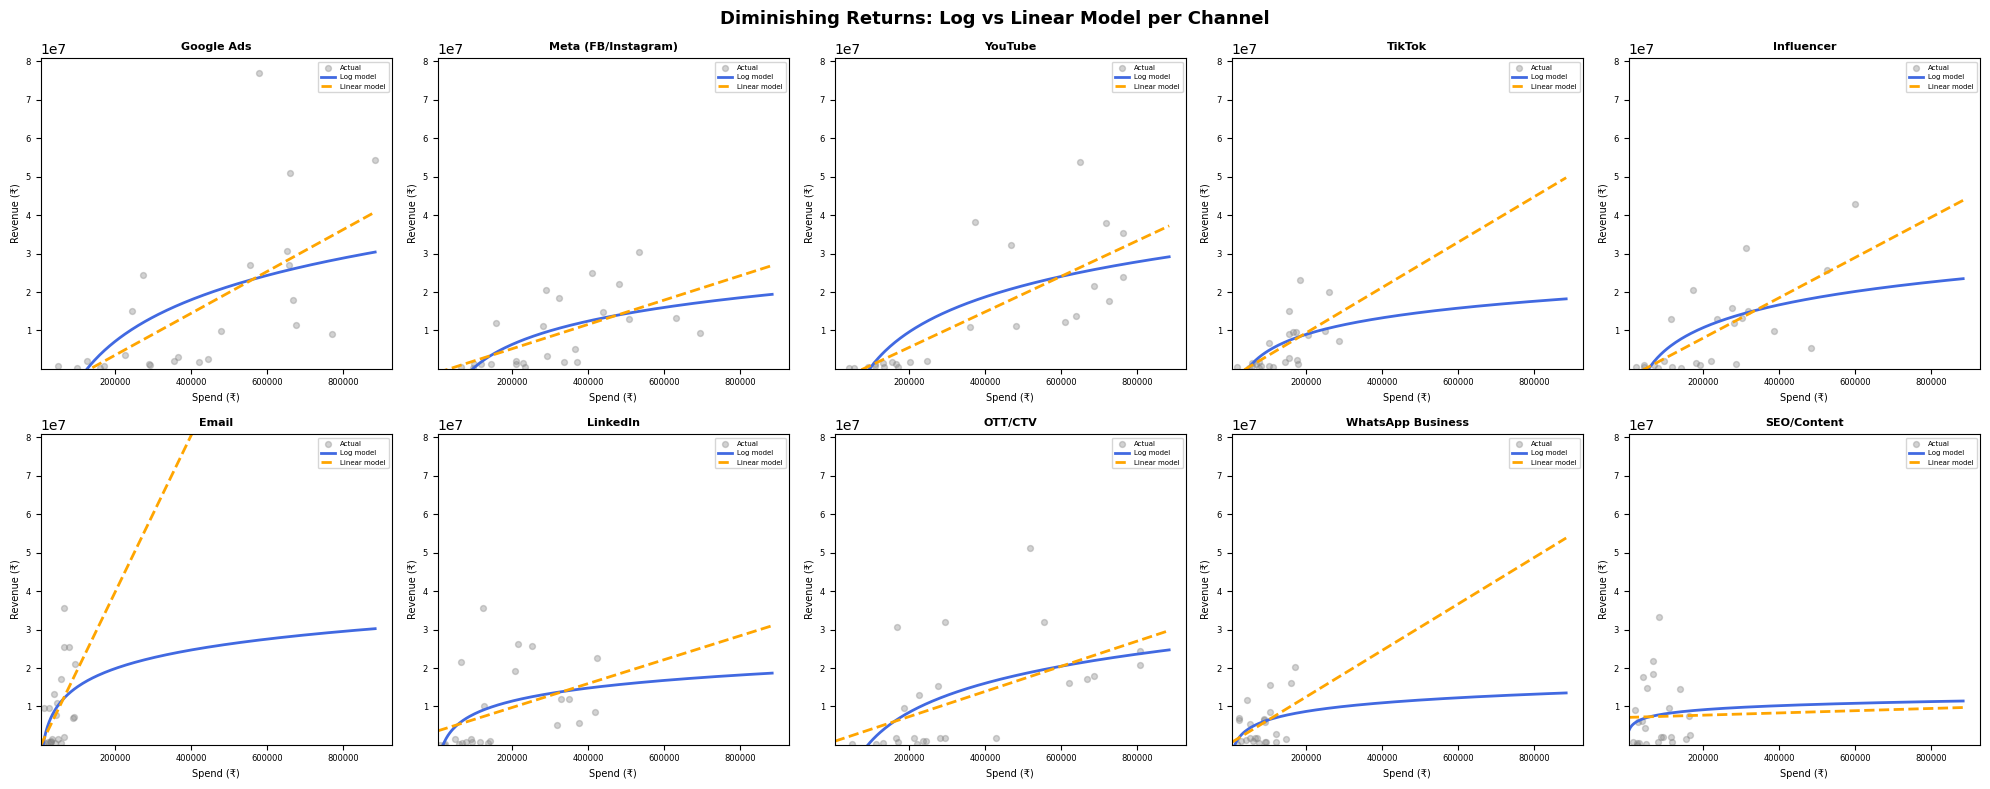

Chart saved!


In [ ]:
channels = df['channel'].unique()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
fig.suptitle('Diminishing Returns: Log vs Linear Model per Channel', fontsize=13, fontweight='bold')

# Global axis limits for standardized scaling across all subplots
global_spend_min = df['ad_spend_inr'].min()
global_spend_max = df['ad_spend_inr'].max()
global_rev_min   = df['revenue_generated_inr'].min()
global_rev_max   = df['revenue_generated_inr'].max()

for i, channel in enumerate(channels):
    sub    = df[df['channel'] == channel].sort_values('ad_spend_inr')
    spend  = sub['ad_spend_inr'].values
    rev    = sub['revenue_generated_inr'].values
    x_range = np.linspace(global_spend_min, global_spend_max, 200)

    # Log model: fit on log-transformed spend
    a, b   = np.polyfit(np.log(spend + 1), rev, 1)
    y_log  = a * np.log(x_range + 1) + b

    # Linear model
    m, c   = np.polyfit(spend, rev, 1)
    y_lin  = m * x_range + c

    axes[i].scatter(spend, rev, alpha=0.35, s=18, color='gray', label='Actual')
    axes[i].plot(x_range, y_log, color='royalblue', lw=2,       label='Log model')
    axes[i].plot(x_range, y_lin, color='orange',    lw=2, ls='--', label='Linear model')
    axes[i].set_title(channel, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Spend (₹)', fontsize=7)
    axes[i].set_ylabel('Revenue (₹)', fontsize=7)
    axes[i].set_xlim(global_spend_min * 0.95, global_spend_max * 1.05)
    axes[i].set_ylim(global_rev_min   * 0.95, global_rev_max   * 1.05)
    axes[i].tick_params(labelsize=6)
    axes[i].legend(fontsize=5)

plt.tight_layout()
plt.savefig('samsung_diminishing_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## Step 7: Channel Performance by Product Tier

Samsung-specific: Budget / Mid-range / Flagship products may respond differently to the same channel.

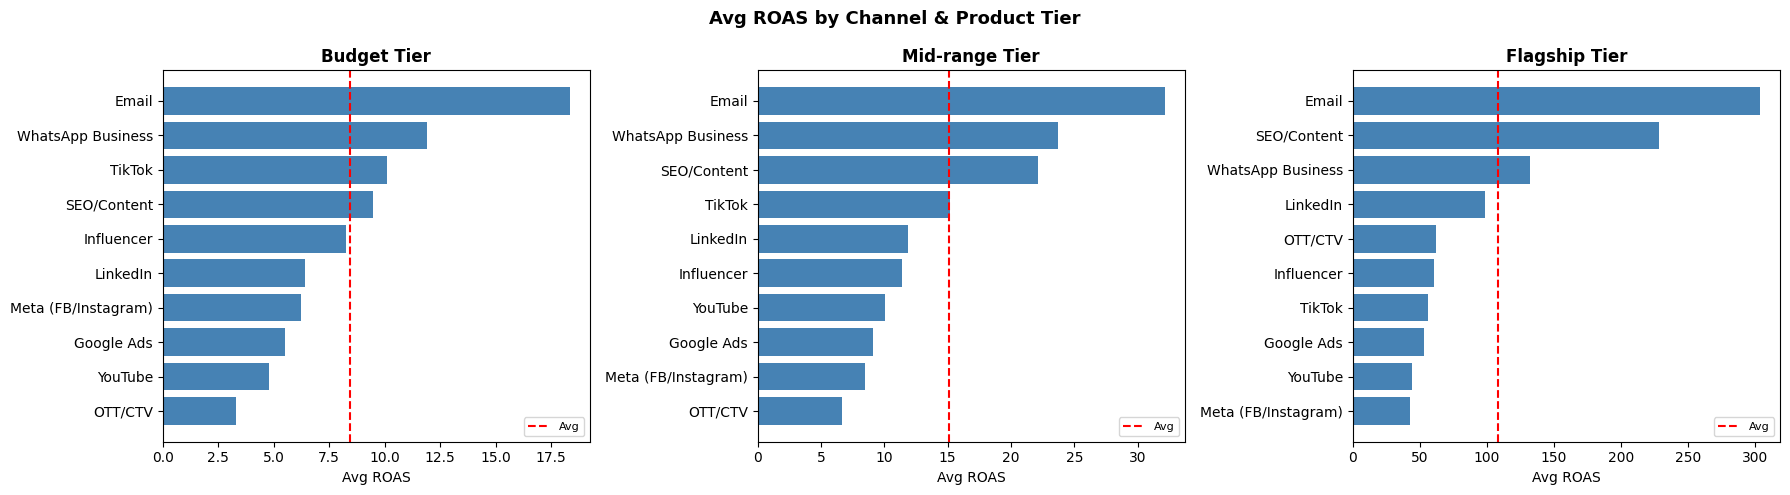

In [ ]:
tier_channel = df.groupby(['product_tier', 'channel']).agg(
    avg_roas     = ('roas', 'mean'),
    avg_marginal = ('marginal_return', 'mean'),
    total_units  = ('units_sold', 'sum')
).reset_index()

tiers  = df['product_tier'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('Avg ROAS by Channel & Product Tier', fontsize=13, fontweight='bold')

for i, tier in enumerate(tiers):
    subset = tier_channel[tier_channel['product_tier'] == tier].sort_values('avg_roas', ascending=True)
    axes[i].barh(subset['channel'], subset['avg_roas'], color='steelblue')
    axes[i].axvline(subset['avg_roas'].mean(), color='red', linestyle='--', label='Avg')
    axes[i].set_title(f'{tier} Tier', fontweight='bold')
    axes[i].set_xlabel('Avg ROAS')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('samsung_tier_channel.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Final Composite Ranking

=== SAMSUNG CHANNEL EFFECTIVENESS RANKING ===
            channel  overall_roas  avg_marginal  log_efficiency  composite_score
              Email    177.136630     74.881363        1.409074            10.00
        SEO/Content     95.408101     49.988153        1.350483             5.83
  WhatsApp Business     64.594756     29.722087        1.328582             3.78
           LinkedIn     51.401025     17.034932        1.261814             1.86
             TikTok     40.938156     10.881443        1.264845             1.36
         Influencer     41.534342     10.088610        1.247008             1.07
            YouTube     36.284149      6.184652        1.222580             0.39
         Google Ads     37.037210      7.068039        1.216371             0.35
            OTT/CTV     35.023113      8.821771        1.211437             0.30
Meta (FB/Instagram)     28.137760      6.518572        1.218358             0.12


/tmp/ipykernel_506/1724908313.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(final['channel'], rotation=45, ha='right')


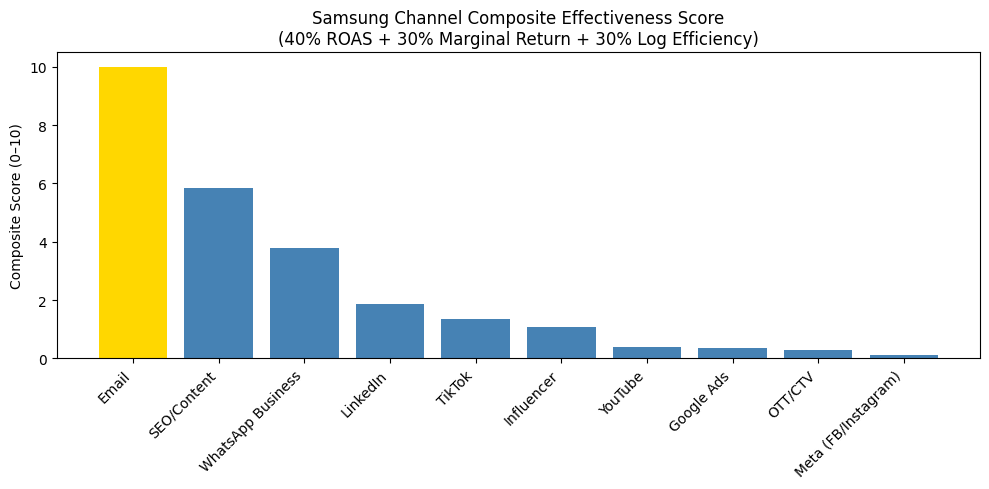

In [ ]:
def norm(s):
    return 10 * (s - s.min()) / (s.max() - s.min())

final = channel_summary.merge(log_metrics[['channel','avg_marginal','log_efficiency']], on='channel')
final['score_roas']      = norm(final['overall_roas'])
final['score_marginal']  = norm(final['avg_marginal'])
final['score_log_eff']   = norm(final['log_efficiency'])
final['composite_score'] = (
    final['score_roas']     * 0.4 +
    final['score_marginal'] * 0.3 +
    final['score_log_eff']  * 0.3
).round(2)

final = final.sort_values('composite_score', ascending=False)
cols  = ['channel','overall_roas','avg_marginal','log_efficiency','composite_score']

print('=== SAMSUNG CHANNEL EFFECTIVENESS RANKING ===')
print(final[cols].to_string(index=False))

# Bar chart of composite score
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['gold' if s == final['composite_score'].max() else 'steelblue' for s in final['composite_score']]
ax.bar(final['channel'], final['composite_score'], color=colors)
ax.set_xticklabels(final['channel'], rotation=45, ha='right')
ax.set_ylabel('Composite Score (0–10)')
ax.set_title('Samsung Channel Composite Effectiveness Score\n(40% ROAS + 30% Marginal Return + 30% Log Efficiency)')
plt.tight_layout()
plt.savefig('samsung_composite_score.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation Guide

| Metric | What it means for Samsung |
|---|---|
| **ROAS** | Revenue per ₹1 spent — which channel pays back the most |
| **Marginal Return** | Extra revenue per log-unit of added spend — channels still worth scaling |
| **Log Efficiency** | log(Revenue) / log(Spend) — fair cross-channel comparison using Section 2.6 concepts |
| **Composite Score** | Overall ranking 0–10 combining all three metrics |

**Key insight:** A channel where the log curve (blue) is much steeper than the linear model (orange dashed) still has significant headroom. A flat log curve means returns are diminishing — time to redistribute spend to higher-scoring channels.